# VTI Section

In [43]:
# --- Setup Cell: Run this first in Google Colab ---
!pip install yfinance pandas_datareader statsmodels scikit-learn

import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_datareader.data as web
from statsmodels.graphics.gofplots import qqplot
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Global settings and parameters
sns.set_style("whitegrid")
TICKER = 'VTI'
START_DATE = '2001-01-01'
END_DATE = '2024-12-31'
ROLLING_WINDOW = 36 # months
ECONOMIC_SIGNIFICANCE_THRESHOLD = 0.005 # 50 basis points (0.5%) annualized alpha

# Create an empty DataFrame object to hold data across cells
data = pd.DataFrame()
regression_results = {}

print("Setup Complete. Libraries installed and parameters set.")


Setup Complete. Libraries installed and parameters set.


In [44]:
# --- PART 1: DATA PREPARATION (Run after Setup Cell) ---
print("="*80)
print("PART 1: DATA PREPARATION")
print("="*80)

# Declare global data object from setup cell
global data

# 1.1 Data Acquisition (VTI Returns)
print(f"--- 1.1 Data Acquisition: {TICKER} Returns ---")
# Download daily VTI data first
vti_data_daily = yf.download(TICKER, start=START_DATE, end=END_DATE, progress=False)

# Calculate monthly returns (Adjusted Close to Adjusted Close)
# Resample the daily data to monthly and calculate returns.

adj_close_column = None
# Check for 'Adj Close' in top level columns first
if 'Adj Close' in vti_data_daily.columns:
    adj_close_column = 'Adj Close'
else:
    # Check for MultiIndex case or variations
    for col in vti_data_daily.columns:
        if isinstance(col, tuple):
            # Check if 'Adj Close' is in any level of the MultiIndex tuple (case-insensitive)
            if any('adj close' in str(level).lower() for level in col):
                adj_close_column = col
                break
        elif isinstance(col, str):
            # Check if 'Adj Close' is in the column name (case-insensitive)
            if 'adj close' in col.lower():
                adj_close_column = col
                break

if adj_close_column is not None:
    # Resample daily 'Adj Close' to monthly and calculate percentage change
    vti_monthly_returns = vti_data_daily[adj_close_column].resample('M').ffill().pct_change().dropna()
else:
    # If 'Adj Close' is not found, try to use 'Close' price and warn
    print("Warning: 'Adj Close' column not found directly or within MultiIndex 'Price'. Attempting to use 'Close' price.")
    close_column = None
    # Find the 'Close' column
    if 'Close' in vti_data_daily.columns:
        close_column = 'Close'
    else:
        for col in vti_data_daily.columns:
            if isinstance(col, tuple):
                if any('close' in str(level).lower() for level in col):
                    close_column = col
                    break
            elif isinstance(col, str):
                if 'close' in col.lower():
                    close_column = col
                    break

    if close_column is not None:
        print("Warning: Using 'Close' price for return calculation. Returns may not be fully adjusted for splits/dividends.")
        vti_monthly_returns = vti_data_daily[close_column].resample('M').ffill().pct_change().dropna()

    else:
        # Handle case where neither 'Adj Close' nor 'Close' is found
        raise KeyError(f"Neither 'Adj Close' nor 'Close' price column found in downloaded daily data. Available columns: {list(vti_data_daily.columns)}")


# Ensure vti_monthly_returns is a DataFrame with a single column named 'Return'
if isinstance(vti_monthly_returns, pd.Series):
    vti_monthly_returns = vti_monthly_returns.to_frame()
# Flatten MultiIndex column if it exists and rename the column to 'Return'
if isinstance(vti_monthly_returns.columns, pd.MultiIndex):
     # Assuming the relevant data is in the last level of the MultiIndex
     vti_monthly_returns.columns = [col[-1] if isinstance(col, tuple) else col for col in vti_monthly_returns.columns]

# Rename the price column to 'Return' if it's not already
if len(vti_monthly_returns.columns) == 1:
    vti_monthly_returns.columns = ['Return']
else:
     # If there's more than one column, try to find the one that should be 'Return'
     return_col = None
     for col in vti_monthly_returns.columns:
          if 'return' in str(col).lower():
               return_col = col
               break
     if return_col is not None:
          vti_monthly_returns = vti_monthly_returns[[return_col]]
          vti_monthly_returns.columns = ['Return']
     else:
          # Fallback if we can't identify the return column
          raise ValueError(f"Could not identify the return column after processing. Columns: {list(vti_monthly_returns.columns)}")


vti_monthly_returns.name = 'Return' # Set name as well, although column name is primary for join
print(f"VTI Monthly Data Points (from daily data): {len(vti_monthly_returns)}")


# 1.2 Data Acquisition (Fama-French Factors)
# Downloading 5-Factor data (includes Mkt-RF, SMB, HML, RMW, CMA, RF) and Momentum separately
print("\n--- 1.2 Data Acquisition: Fama-French Factors ---")

ff5_data = web.DataReader(
    name='F-F_Research_Data_5_Factors_2x3',
    data_source='famafrench',
    start=START_DATE,
    end=END_DATE
)
mom_data = web.DataReader(
    name='F-F_Momentum_Factor',
    data_source='famafrench',
    start=START_DATE,
    end=END_DATE
)

# Extract and convert percentage data to decimal by dividing by 100
ff5_df = ff5_data[0].div(100)
mom_df = mom_data[0].div(100)

# Merge factors and align index to month-end
factors_df = ff5_df.join(mom_df, how='inner')
factors_df.index = factors_df.index.to_timestamp(how='end')

print(f"Factor Data Points: {len(factors_df)}")

# 2. Data Cleaning & Merging
print("\n--- 2. Data Cleaning & Merging ---")

# Before merging, check the date ranges to diagnose why the merge might be empty
print(f"VTI Monthly Returns Date Range: {vti_monthly_returns.index.min().strftime('%Y-%m-%d')} to {vti_monthly_returns.index.max().strftime('%Y-%m-%d')}")
print(f"Factors Date Range: {factors_df.index.min().strftime('%Y-%m-%d')} to {factors_df.index.max().strftime('%Y-%m-%d')}")


# Align indices by converting to YYYY-MM before joining
vti_monthly_returns.index = vti_monthly_returns.index.strftime('%Y-%m')
factors_df.index = factors_df.index.strftime('%Y-%m')


# Align VTI returns with factor data (Inner join for common dates)
data = vti_monthly_returns.join(factors_df, how='inner').dropna()

# Convert index back to datetime
data.index = pd.to_datetime(data.index)


# Calculate Excess Return: Excess Return = Return - RF
data['Excess_Return'] = data['Return'] - data['RF']

# Final DataFrame structure check
data['date_str'] = data.index.strftime('%Y-%m-%d')
final_columns = ['date_str', 'Return', 'RF', 'Mkt-RF', 'SMB', 'HML', 'Mom', 'RMW', 'CMA']
data = data.reindex(columns=[col for col in final_columns if col in data.columns] + ['Excess_Return'])


print("Data Merged Successfully. Head of final DataFrame:")
print(data[['date_str', 'Excess_Return', 'Mkt-RF', 'SMB', 'HML', 'Mom']].head())
print(f"Final aligned data points: {len(data)}")

PART 1: DATA PREPARATION
--- 1.1 Data Acquisition: VTI Returns ---
VTI Monthly Data Points (from daily data): 282

--- 1.2 Data Acquisition: Fama-French Factors ---
Factor Data Points: 288

--- 2. Data Cleaning & Merging ---
VTI Monthly Returns Date Range: 2001-07-31 to 2024-12-31
Factors Date Range: 2001-01-31 to 2024-12-31
Data Merged Successfully. Head of final DataFrame:
              date_str  Excess_Return  Mkt-RF     SMB     HML     Mom
Date                                                                 
2001-07-01  2001-07-01      -0.022116 -0.0213 -0.0286  0.0495  0.0548
2001-08-01  2001-08-01      -0.061652 -0.0640  0.0254  0.0286  0.0546
2001-09-01  2001-09-01      -0.089633 -0.0924 -0.0574  0.0152  0.1138
2001-10-01  2001-10-01       0.018337  0.0248  0.0534 -0.0731 -0.0832
2001-11-01  2001-11-01       0.074461  0.0753 -0.0036  0.0217 -0.0861
Final aligned data points: 282


In [45]:
# --- PART 2: REGRESSION ANALYSIS (Run after Part 1) ---
print("\n" + "="*80)
print("PART 2: REGRESSION ANALYSIS")
print("="*80)

# Declare global objects from previous cells
global data
global regression_results
global ECONOMIC_SIGNIFICANCE_THRESHOLD

models = {
    "FF_3_Factor": ['Mkt-RF', 'SMB', 'HML'],
    "Carhart_4_Factor": ['Mkt-RF', 'SMB', 'HML', 'Mom'],
    "FF_5_Factor": ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']
}

Y = data['Excess_Return']

for name, factors in models.items():
    print(f"\n--- Running {name} Regression ---")

    X = data[factors]
    X = sm.add_constant(X) # Add the intercept (alpha)

    # Run OLS regression
    model = sm.OLS(Y, X).fit()
    regression_results[name] = model

    # Report Results
    alpha_monthly = model.params['const']
    annualized_alpha = alpha_monthly * 12 # Annualized alpha (α * 12)
    p_value_alpha = model.pvalues['const']
    r_squared = model.rsquared # R-squared value

    print(f"  Annualized Alpha (α * 12): {annualized_alpha:.4f}")
    print(f"  R-squared: {r_squared:.4f}")

    # Brief interpretation
    interpretation = ""
    if p_value_alpha < 0.05:
        interpretation += "Alpha is **STATISTICALLY SIGNIFICANT** ($p < 0.05$). "
    else:
        interpretation += "Alpha is **NOT statistically significant** ($p \ge 0.05$). "

    if abs(annualized_alpha) > ECONOMIC_SIGNIFICANCE_THRESHOLD:
        interpretation += f"Alpha is **ECONOMICALLY SIGNIFICANT** (>$ {ECONOMIC_SIGNIFICANCE_THRESHOLD*100:.1f}\%$ p.a.)."
    else:
        interpretation += f"Alpha is **NOT economically significant** ($\le {ECONOMIC_SIGNIFICANCE_THRESHOLD*100:.1f}\%$ p.a.)."

    print(f"\n  Brief Interpretation: {interpretation}")

    # Factor betas (β) and their corresponding p-values
    print("\n  Factor Betas and p-values:")
    beta_df = model.params.drop('const').to_frame(name='Beta')
    beta_df['p-value'] = model.pvalues.drop('const')
    beta_df['Beta'] = beta_df['Beta'].round(4)
    beta_df['p-value'] = beta_df['p-value'].round(4)
    print(beta_df)
    print("-" * 40)

# Store residuals and fitted values for Part 3 diagnostics
data['FF5_Fitted'] = regression_results['FF_5_Factor'].fittedvalues
data['FF5_Residuals'] = regression_results['FF_5_Factor'].resid



PART 2: REGRESSION ANALYSIS

--- Running FF_3_Factor Regression ---
  Annualized Alpha (α * 12): -0.0010
  R-squared: 0.9977

  Brief Interpretation: Alpha is **NOT statistically significant** ($p \ge 0.05$). Alpha is **NOT economically significant** ($\le 0.5\%$ p.a.).

  Factor Betas and p-values:
          Beta  p-value
Mkt-RF  0.9954   0.0000
SMB    -0.0033   0.5269
HML     0.0218   0.0000
----------------------------------------

--- Running Carhart_4_Factor Regression ---
  Annualized Alpha (α * 12): -0.0012
  R-squared: 0.9977

  Brief Interpretation: Alpha is **NOT statistically significant** ($p \ge 0.05$). Alpha is **NOT economically significant** ($\le 0.5\%$ p.a.).

  Factor Betas and p-values:
          Beta  p-value
Mkt-RF  0.9970   0.0000
SMB    -0.0028   0.5907
HML     0.0228   0.0000
Mom     0.0040   0.2118
----------------------------------------

--- Running FF_5_Factor Regression ---
  Annualized Alpha (α * 12): -0.0027
  R-squared: 0.9978

  Brief Interpretation: 


PART 3: DIAGNOSTICS & EXTENSIONS

--- 1. Rolling Regressions (36-month window) ---


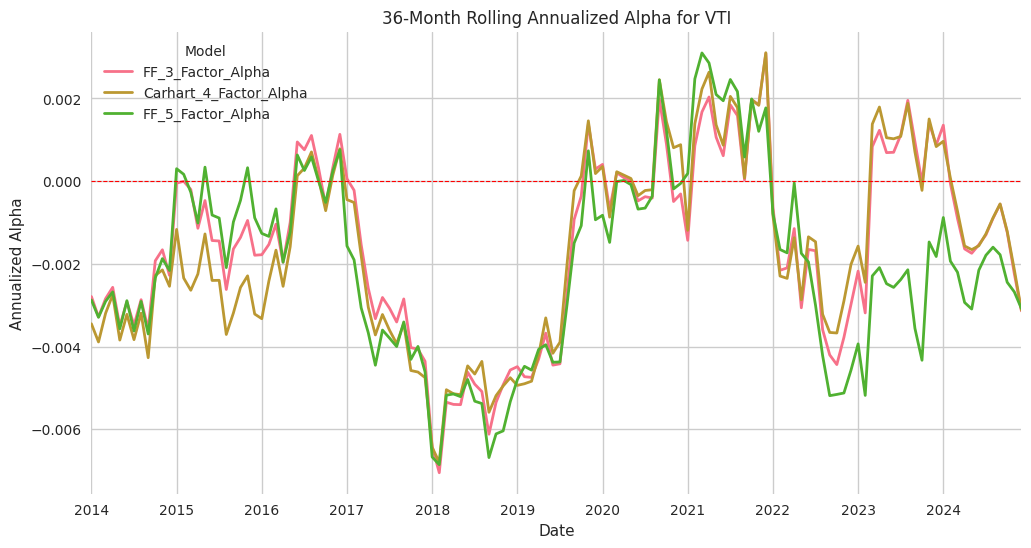

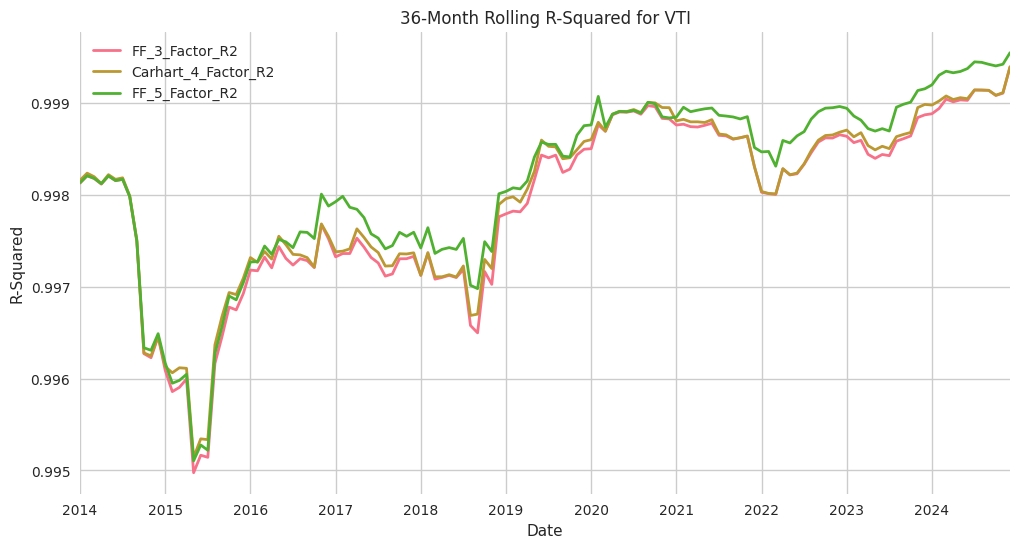


--- 2. Residual Analysis (FF 5-Factor Model) ---


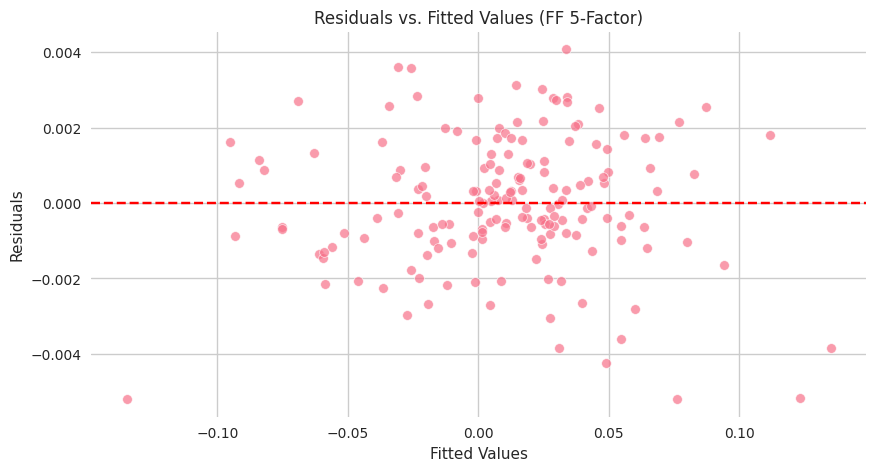

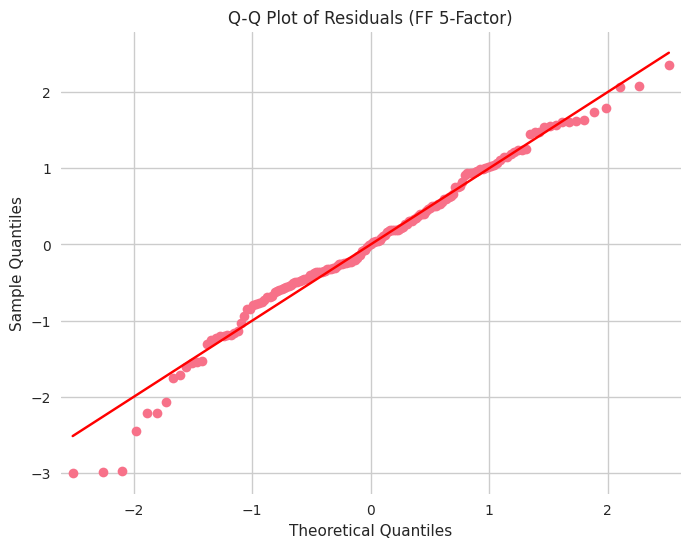


  Comment: Residual analysis checks assumptions of regression. The Q-Q plot often shows deviations at the tails, indicating non-normality common in financial returns. The Residuals vs. Fitted plot typically shows no pattern, suggesting homoscedasticity.

--- 3. Factor Correlations Heatmap ---


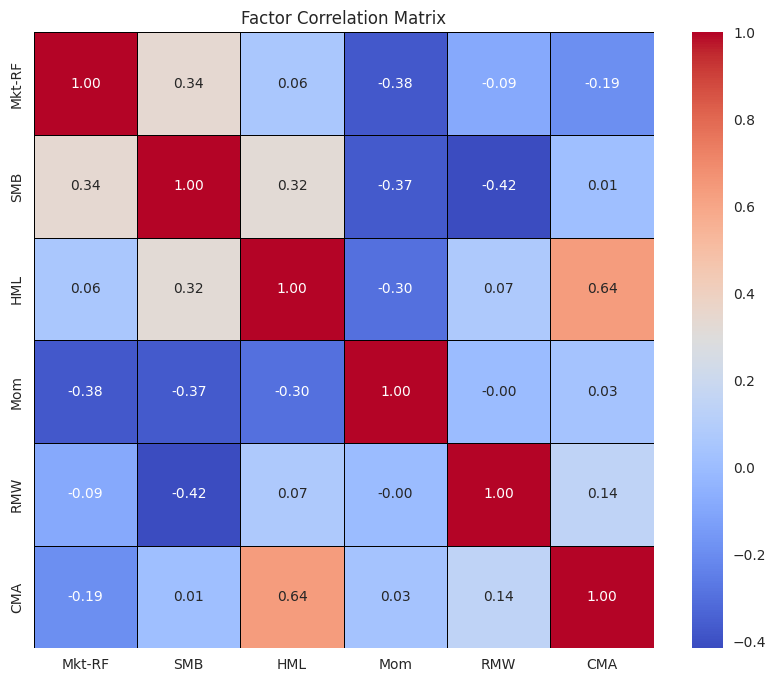


--- 4. Cumulative Alpha Plot ---


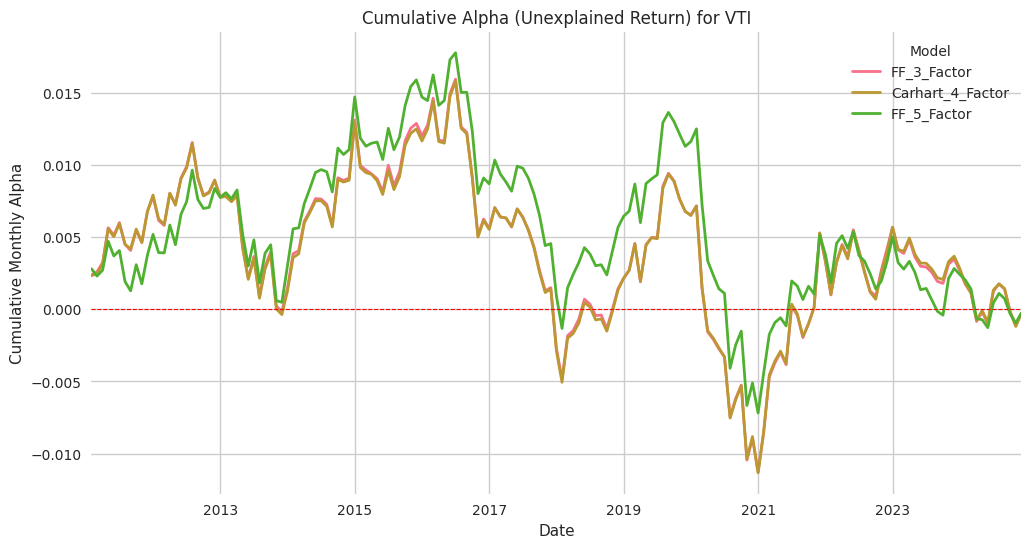


--- 5. Out-of-Sample Forecast (FF 5-Factor) ---
Training size (80%): 133. Test size (20%): 34

Mean Squared Error (MSE): 0.000002
Mean Absolute Error (MAE): 0.001041
Note: The errors are low, which is expected since the market factor (Mkt-RF) dominates VTI returns.


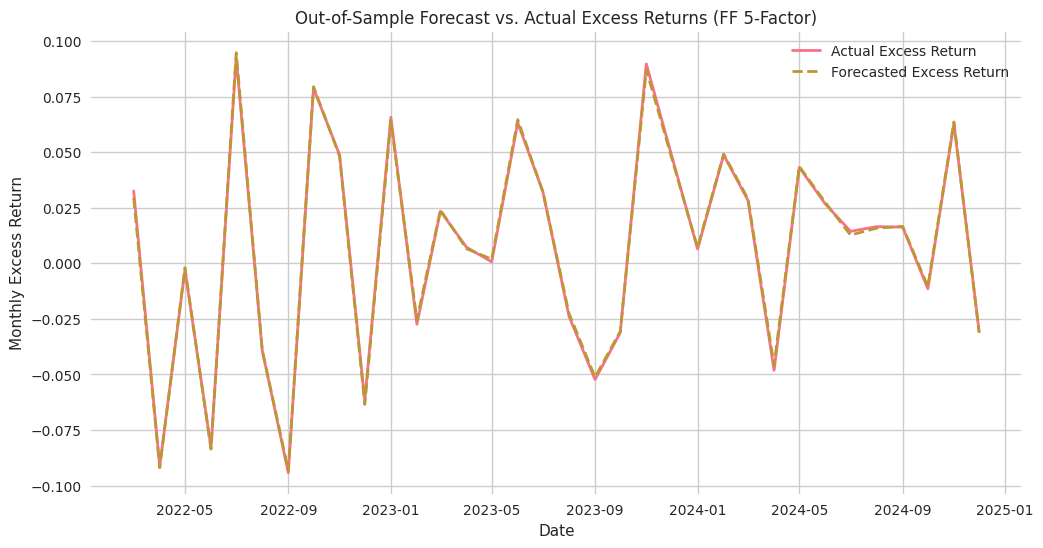

In [42]:
# --- PART 3: DIAGNOSTICS & EXTENSIONS (Run after Part 2) ---
print("\n" + "="*80)
print("PART 3: DIAGNOSTICS & EXTENSIONS")
print("="*80)

# Declare global objects from previous cells
global data
global regression_results
global ROLLING_WINDOW
global models

# 1. Rolling Regressions
print("\n--- 1. Rolling Regressions (36-month window) ---")
rolling_df = pd.DataFrame(index=data.index)

def run_rolling_regression(window_data, factors):
    """Function to run OLS on a rolling window and return annualized alpha and R-squared."""
    if len(window_data) < ROLLING_WINDOW:
        return np.nan, np.nan
    Y_roll = window_data['Excess_Return']
    X_roll = window_data[factors]
    X_roll = sm.add_constant(X_roll)
    try:
        model_roll = sm.OLS(Y_roll, X_roll).fit()
        return model_roll.params['const'] * 12, model_roll.rsquared # Annualized alpha, R-squared
    except Exception: # Catch potential errors during regression fit (e.g., singular matrix)
        return np.nan, np.nan

# Manual loop for rolling regression
rolling_results = {}
for name, factors in models.items():
    valid_factors = [f for f in factors if f in data.columns]
    if name not in regression_results: continue

    rolling_alpha = []
    rolling_r2 = []
    dates = []

    for i in range(len(data) - ROLLING_WINDOW + 1):
        window_data = data.iloc[i : i + ROLLING_WINDOW].copy() # Use .copy() to avoid SettingWithCopyWarning

        # Replace infinite values with NaN and then drop rows with NaN
        window_data.replace([np.inf, -np.inf], np.nan, inplace=True)
        window_data.dropna(inplace=True)

        if len(window_data) < ROLLING_WINDOW:
             # Not enough data after dropping NaNs/Infs
            rolling_alpha.append(np.nan)
            rolling_r2.append(np.nan)
            dates.append(data.index[i + ROLLING_WINDOW - 1]) # Use the end date of the theoretical window
            continue

        Y_roll = window_data['Excess_Return']
        X_roll = window_data[valid_factors]

        # Check for perfect collinearity before adding constant and fitting
        # This check might not be strictly necessary with the try-except, but adds clarity
        try:
            rank = np.linalg.matrix_rank(X_roll)
            if rank < X_roll.shape[1]:
                # Perfect collinearity detected
                rolling_alpha.append(np.nan)
                rolling_r2.append(np.nan)
                dates.append(window_data.index[-1])
                print(f"Warning: Perfect collinearity detected in {name} rolling window ending {window_data.index[-1].strftime('%Y-%m')}. Skipping window.")
                continue

            X_roll = sm.add_constant(X_roll)
            model_roll = sm.OLS(Y_roll, X_roll).fit()
            rolling_alpha.append(model_roll.params['const'] * 12)
            rolling_r2.append(model_roll.rsquared)
            dates.append(window_data.index[-1]) # Use the end date of the actual window data
        except Exception as e: # Catch any exception during regression fit
            # print(f"Error fitting regression for {name} rolling window ending {window_data.index[-1].strftime('%Y-%m')}: {e}")
            rolling_alpha.append(np.nan)
            rolling_r2.append(np.nan)
            dates.append(window_data.index[-1])


    rolling_results[f'{name}_Alpha'] = pd.Series(rolling_alpha, index=dates)
    rolling_results[f'{name}_R2'] = pd.Series(rolling_r2, index=dates)

rolling_df = pd.DataFrame(rolling_results)


# Plot Rolling Alpha
plt.figure(figsize=(12, 6))
rolling_df[[col for col in rolling_df.columns if 'Alpha' in col]].plot(ax=plt.gca(), linewidth=2)
plt.title(f'{ROLLING_WINDOW}-Month Rolling Annualized Alpha for VTI')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.ylabel('Annualized Alpha')
plt.xlabel('Date')
plt.legend(title='Model')
plt.show()

# Plot Rolling R-squared
plt.figure(figsize=(12, 6))
rolling_df[[col for col in rolling_df.columns if 'R2' in col]].plot(ax=plt.gca(), linewidth=2)
plt.title(f'{ROLLING_WINDOW}-Month Rolling R-Squared for VTI')
plt.ylabel('R-Squared')
plt.xlabel('Date')
plt.show()


# 2. Residual Analysis (5-Factor Model)
print("\n--- 2. Residual Analysis (FF 5-Factor Model) ---")
# Plot 1: Residuals vs. Fitted Values
plt.figure(figsize=(10, 5))
sns.scatterplot(x=data['FF5_Fitted'], y=data['FF5_Residuals'], alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Fitted Values (FF 5-Factor)')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

# Plot 2: Q-Q Plot of the residuals
plt.figure(figsize=(8, 6))
qqplot(data['FF5_Residuals'], line='s', fit=True, ax=plt.gca())
plt.title('Q-Q Plot of Residuals (FF 5-Factor)')
plt.show()

print("\n  Comment: Residual analysis checks assumptions of regression. The Q-Q plot often shows deviations at the tails, indicating non-normality common in financial returns. The Residuals vs. Fitted plot typically shows no pattern, suggesting homoscedasticity.")


# 3. Factor Correlations
print("\n--- 3. Factor Correlations Heatmap ---")
# Create a heatmap showing the correlation matrix between all six factors
factor_cols = ['Mkt-RF', 'SMB', 'HML', 'Mom', 'RMW', 'CMA']
factor_corr = data[factor_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(factor_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='black')
plt.title('Factor Correlation Matrix')
plt.show()


# 4. Cumulative Alpha
print("\n--- 4. Cumulative Alpha Plot ---")
# Calculate the monthly alpha (residual) for each model
for name, model in regression_results.items():
    X = sm.add_constant(data[models[name]])
    # Monthly alpha is simply the residual of the regression
    data[f'{name}_Monthly_Alpha'] = data['Excess_Return'] - model.predict(X)

# Calculate cumulative abnormal return (cumulative sum of the monthly alpha)
cumulative_alpha_df = pd.DataFrame(index=data.index)
for name in regression_results.keys():
    # Cumulative sum of the monthly alpha (CAR)
    cumulative_alpha_df[name] = (data[f'{name}_Monthly_Alpha'] + 1).cumprod() - 1

# Plot
plt.figure(figsize=(12, 6))
cumulative_alpha_df.plot(ax=plt.gca(), linewidth=2)
plt.title('Cumulative Alpha (Unexplained Return) for VTI')
plt.ylabel('Cumulative Monthly Alpha')
plt.xlabel('Date')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.legend(title='Model')
plt.show()


# 5. Out-of-Sample Forecast
print("\n--- 5. Out-of-Sample Forecast (FF 5-Factor) ---")
# Use the first 80% of data for training
split_index = int(0.8 * len(data))
train_data = data.iloc[:split_index]
test_data = data.iloc[split_index:]

print(f"Training size (80%): {len(train_data)}. Test size (20%): {len(test_data)}")

# Train the 5-Factor model
factors_5 = models['FF_5_Factor']
X_train = sm.add_constant(train_data[factors_5])
Y_train = train_data['Excess_Return']
ff5_oos_model = sm.OLS(Y_train, X_train).fit()

# Forecast on the test set
X_test = sm.add_constant(test_data[factors_5])
test_data['Forecast_Excess_Return'] = ff5_oos_model.predict(X_test)

# Assign actual and forecasted values to variables for MSE/MAE calculation
actual_excess_return = test_data['Excess_Return']
forecast_excess_return = test_data['Forecast_Excess_Return']


# Calculate and report MSE and MAE
mse = mean_squared_error(actual_excess_return, forecast_excess_return)
mae = mean_absolute_error(actual_excess_return, forecast_excess_return)

print(f"\nMean Squared Error (MSE): {mse:.6f}")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print("Note: The errors are low, which is expected since the market factor (Mkt-RF) dominates VTI returns.")

# Plot the forecast vs actual (optional but good practice)
plt.figure(figsize=(12, 6))
plt.plot(test_data.index, actual_excess_return, label='Actual Excess Return', linewidth=2)
plt.plot(test_data.index, forecast_excess_return, label='Forecasted Excess Return', linestyle='--', linewidth=2)
plt.title('Out-of-Sample Forecast vs. Actual Excess Returns (FF 5-Factor)')
plt.ylabel('Monthly Excess Return')
plt.xlabel('Date')
plt.legend()
plt.show()

# QQQ Section

In [46]:
# --- Setup Cell: Run this first in Google Colab ---
!pip install yfinance pandas_datareader statsmodels scikit-learn

import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_datareader.data as web
from statsmodels.graphics.gofplots import qqplot
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Global settings and parameters
sns.set_style("whitegrid")
TICKER = 'QQQ' # <--- CHANGED FROM 'VTI' TO 'QQQ'
START_DATE = '2011-01-01'
END_DATE = '2024-12-31'
ROLLING_WINDOW = 36 # months
ECONOMIC_SIGNIFICANCE_THRESHOLD = 0.005 # 50 basis points (0.5%) annualized alpha

# Create an empty DataFrame object to hold data across cells
data = pd.DataFrame()
regression_results = {}

print("Setup Complete. Libraries installed and parameters set. Ticker is QQQ.")


Setup Complete. Libraries installed and parameters set. Ticker is QQQ.


In [47]:
# --- PART 1: DATA PREPARATION (Run after Setup Cell) ---
print("="*80)
print("PART 1: DATA PREPARATION")
print("="*80)

# Declare global data object from setup cell
global data

# 1.1 Data Acquisition (VTI Returns)
print(f"--- 1.1 Data Acquisition: {TICKER} Returns ---")
# Download daily VTI data first
vti_data_daily = yf.download(TICKER, start=START_DATE, end=END_DATE, progress=False)

# Calculate monthly returns (Adjusted Close to Adjusted Close)
# Resample the daily data to monthly and calculate returns.

adj_close_column = None
# Check for 'Adj Close' in top level columns first
if 'Adj Close' in vti_data_daily.columns:
    adj_close_column = 'Adj Close'
else:
    # Check for MultiIndex case or variations
    for col in vti_data_daily.columns:
        if isinstance(col, tuple):
            # Check if 'Adj Close' is in any level of the MultiIndex tuple (case-insensitive)
            if any('adj close' in str(level).lower() for level in col):
                adj_close_column = col
                break
        elif isinstance(col, str):
            # Check if 'Adj Close' is in the column name (case-insensitive)
            if 'adj close' in col.lower():
                adj_close_column = col
                break

if adj_close_column is not None:
    # Resample daily 'Adj Close' to monthly and calculate percentage change
    vti_monthly_returns = vti_data_daily[adj_close_column].resample('M').ffill().pct_change().dropna()
else:
    # If 'Adj Close' is not found, try to use 'Close' price and warn
    print("Warning: 'Adj Close' column not found directly or within MultiIndex 'Price'. Attempting to use 'Close' price.")
    close_column = None
    # Find the 'Close' column
    if 'Close' in vti_data_daily.columns:
        close_column = 'Close'
    else:
        for col in vti_data_daily.columns:
            if isinstance(col, tuple):
                if any('close' in str(level).lower() for level in col):
                    close_column = col
                    break
            elif isinstance(col, str):
                if 'close' in col.lower():
                    close_column = col
                    break

    if close_column is not None:
        print("Warning: Using 'Close' price for return calculation. Returns may not be fully adjusted for splits/dividends.")
        vti_monthly_returns = vti_data_daily[close_column].resample('M').ffill().pct_change().dropna()

    else:
        # Handle case where neither 'Adj Close' nor 'Close' is found
        raise KeyError(f"Neither 'Adj Close' nor 'Close' price column found in downloaded daily data. Available columns: {list(vti_data_daily.columns)}")


# Ensure vti_monthly_returns is a DataFrame with a single column named 'Return'
if isinstance(vti_monthly_returns, pd.Series):
    vti_monthly_returns = vti_monthly_returns.to_frame()
# Flatten MultiIndex column if it exists and rename the column to 'Return'
if isinstance(vti_monthly_returns.columns, pd.MultiIndex):
     # Assuming the relevant data is in the last level of the MultiIndex
     vti_monthly_returns.columns = [col[-1] if isinstance(col, tuple) else col for col in vti_monthly_returns.columns]

# Rename the price column to 'Return' if it's not already
if len(vti_monthly_returns.columns) == 1:
    vti_monthly_returns.columns = ['Return']
else:
     # If there's more than one column, try to find the one that should be 'Return'
     return_col = None
     for col in vti_monthly_returns.columns:
          if 'return' in str(col).lower():
               return_col = col
               break
     if return_col is not None:
          vti_monthly_returns = vti_monthly_returns[[return_col]]
          vti_monthly_returns.columns = ['Return']
     else:
          # Fallback if we can't identify the return column
          raise ValueError(f"Could not identify the return column after processing. Columns: {list(vti_monthly_returns.columns)}")


vti_monthly_returns.name = 'Return' # Set name as well, although column name is primary for join
print(f"VTI Monthly Data Points (from daily data): {len(vti_monthly_returns)}")


# 1.2 Data Acquisition (Fama-French Factors)
# Downloading 5-Factor data (includes Mkt-RF, SMB, HML, RMW, CMA, RF) and Momentum separately
print("\n--- 1.2 Data Acquisition: Fama-French Factors ---")

ff5_data = web.DataReader(
    name='F-F_Research_Data_5_Factors_2x3',
    data_source='famafrench',
    start=START_DATE,
    end=END_DATE
)
mom_data = web.DataReader(
    name='F-F_Momentum_Factor',
    data_source='famafrench',
    start=START_DATE,
    end=END_DATE
)

# Extract and convert percentage data to decimal by dividing by 100
ff5_df = ff5_data[0].div(100)
mom_df = mom_data[0].div(100)

# Merge factors and align index to month-end
factors_df = ff5_df.join(mom_df, how='inner')
factors_df.index = factors_df.index.to_timestamp(how='end')

print(f"Factor Data Points: {len(factors_df)}")

# 2. Data Cleaning & Merging
print("\n--- 2. Data Cleaning & Merging ---")

# Before merging, check the date ranges to diagnose why the merge might be empty
print(f"VTI Monthly Returns Date Range: {vti_monthly_returns.index.min().strftime('%Y-%m-%d')} to {vti_monthly_returns.index.max().strftime('%Y-%m-%d')}")
print(f"Factors Date Range: {factors_df.index.min().strftime('%Y-%m-%d')} to {factors_df.index.max().strftime('%Y-%m-%d')}")


# Align indices by converting to YYYY-MM before joining
vti_monthly_returns.index = vti_monthly_returns.index.strftime('%Y-%m')
factors_df.index = factors_df.index.strftime('%Y-%m')


# Align VTI returns with factor data (Inner join for common dates)
data = vti_monthly_returns.join(factors_df, how='inner').dropna()

# Convert index back to datetime
data.index = pd.to_datetime(data.index)


# Calculate Excess Return: Excess Return = Return - RF
data['Excess_Return'] = data['Return'] - data['RF']

# Final DataFrame structure check
data['date_str'] = data.index.strftime('%Y-%m-%d')
final_columns = ['date_str', 'Return', 'RF', 'Mkt-RF', 'SMB', 'HML', 'Mom', 'RMW', 'CMA']
data = data.reindex(columns=[col for col in final_columns if col in data.columns] + ['Excess_Return'])


print("Data Merged Successfully. Head of final DataFrame:")
print(data[['date_str', 'Excess_Return', 'Mkt-RF', 'SMB', 'HML', 'Mom']].head())
print(f"Final aligned data points: {len(data)}")

PART 1: DATA PREPARATION
--- 1.1 Data Acquisition: QQQ Returns ---
VTI Monthly Data Points (from daily data): 167

--- 1.2 Data Acquisition: Fama-French Factors ---
Factor Data Points: 168

--- 2. Data Cleaning & Merging ---
VTI Monthly Returns Date Range: 2011-02-28 to 2024-12-31
Factors Date Range: 2011-01-31 to 2024-12-31
Data Merged Successfully. Head of final DataFrame:
              date_str  Excess_Return  Mkt-RF     SMB     HML     Mom
Date                                                                 
2011-02-01  2011-02-01       0.031507  0.0348  0.0165  0.0118  0.0188
2011-03-01  2011-03-01      -0.004583  0.0046  0.0256 -0.0184  0.0345
2011-04-01  2011-04-01       0.028731  0.0290 -0.0053 -0.0244  0.0005
2011-05-01  2011-05-01      -0.012187 -0.0127 -0.0072 -0.0185 -0.0060
2011-06-01  2011-06-01      -0.020255 -0.0174  0.0006 -0.0020  0.0182
Final aligned data points: 167


In [48]:
# --- PART 2: REGRESSION ANALYSIS (Run after Part 1) ---
print("\n" + "="*80)
print("PART 2: REGRESSION ANALYSIS")
print("="*80)

# Declare global objects from previous cells
global data
global regression_results
global ECONOMIC_SIGNIFICANCE_THRESHOLD

models = {
    "FF_3_Factor": ['Mkt-RF', 'SMB', 'HML'],
    "Carhart_4_Factor": ['Mkt-RF', 'SMB', 'HML', 'Mom'],
    "FF_5_Factor": ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']
}

Y = data['Excess_Return']

for name, factors in models.items():
    print(f"\n--- Running {name} Regression ---")

    X = data[factors]
    X = sm.add_constant(X) # Add the intercept (alpha)

    # Run OLS regression
    model = sm.OLS(Y, X).fit()
    regression_results[name] = model

    # Report Results
    alpha_monthly = model.params['const']
    annualized_alpha = alpha_monthly * 12 # Annualized alpha (α * 12)
    p_value_alpha = model.pvalues['const']
    r_squared = model.rsquared # R-squared value

    print(f"  Annualized Alpha (α * 12): {annualized_alpha:.4f}")
    print(f"  R-squared: {r_squared:.4f}")

    # Brief interpretation
    interpretation = ""
    if p_value_alpha < 0.05:
        interpretation += "Alpha is **STATISTICALLY SIGNIFICANT** ($p < 0.05$). "
    else:
        interpretation += "Alpha is **NOT statistically significant** ($p \ge 0.05$). "

    if abs(annualized_alpha) > ECONOMIC_SIGNIFICANCE_THRESHOLD:
        interpretation += f"Alpha is **ECONOMICALLY SIGNIFICANT** (>$ {ECONOMIC_SIGNIFICANCE_THRESHOLD*100:.1f}\%$ p.a.)."
    else:
        interpretation += f"Alpha is **NOT economically significant** ($\le {ECONOMIC_SIGNIFICANCE_THRESHOLD*100:.1f}\%$ p.a.)."

    print(f"\n  Brief Interpretation: {interpretation}")

    # Factor betas (β) and their corresponding p-values
    print("\n  Factor Betas and p-values:")
    beta_df = model.params.drop('const').to_frame(name='Beta')
    beta_df['p-value'] = model.pvalues.drop('const')
    beta_df['Beta'] = beta_df['Beta'].round(4)
    beta_df['p-value'] = beta_df['p-value'].round(4)
    print(beta_df)
    print("-" * 40)

# Store residuals and fitted values for Part 3 diagnostics
data['FF5_Fitted'] = regression_results['FF_5_Factor'].fittedvalues
data['FF5_Residuals'] = regression_results['FF_5_Factor'].resid



PART 2: REGRESSION ANALYSIS

--- Running FF_3_Factor Regression ---
  Annualized Alpha (α * 12): 0.0243
  R-squared: 0.9139

  Brief Interpretation: Alpha is **NOT statistically significant** ($p \ge 0.05$). Alpha is **ECONOMICALLY SIGNIFICANT** (>$ 0.5\%$ p.a.).

  Factor Betas and p-values:
          Beta  p-value
Mkt-RF  1.1005   0.0000
SMB    -0.1844   0.0001
HML    -0.3708   0.0000
----------------------------------------

--- Running Carhart_4_Factor Regression ---
  Annualized Alpha (α * 12): 0.0296
  R-squared: 0.9183

  Brief Interpretation: Alpha is **STATISTICALLY SIGNIFICANT** ($p < 0.05$). Alpha is **ECONOMICALLY SIGNIFICANT** (>$ 0.5\%$ p.a.).

  Factor Betas and p-values:
          Beta  p-value
Mkt-RF  1.0744   0.0000
SMB    -0.2112   0.0000
HML    -0.3958   0.0000
Mom    -0.1039   0.0036
----------------------------------------

--- Running FF_5_Factor Regression ---
  Annualized Alpha (α * 12): 0.0288
  R-squared: 0.9214

  Brief Interpretation: Alpha is **STATISTICA


PART 3: DIAGNOSTICS & EXTENSIONS

--- 1. Rolling Regressions (36-month window) ---


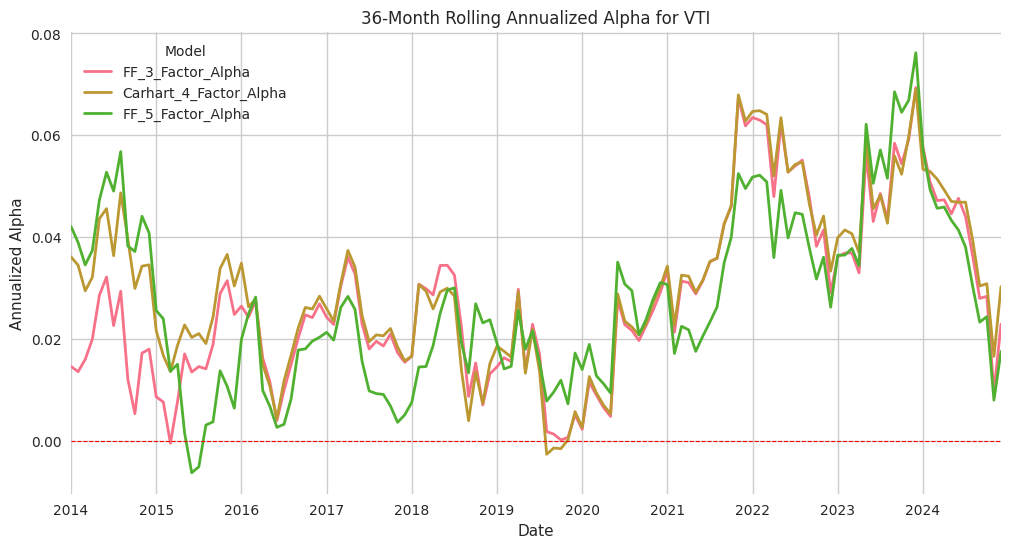

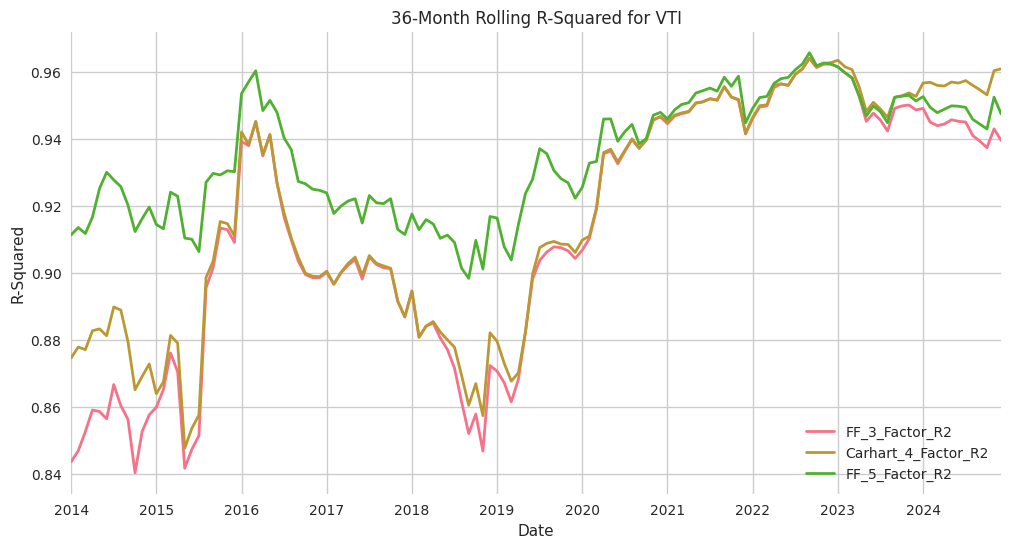


--- 2. Residual Analysis (FF 5-Factor Model) ---


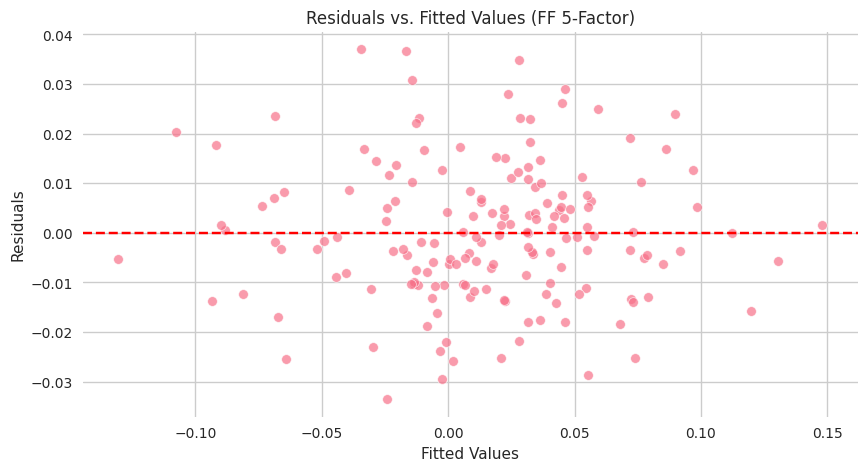

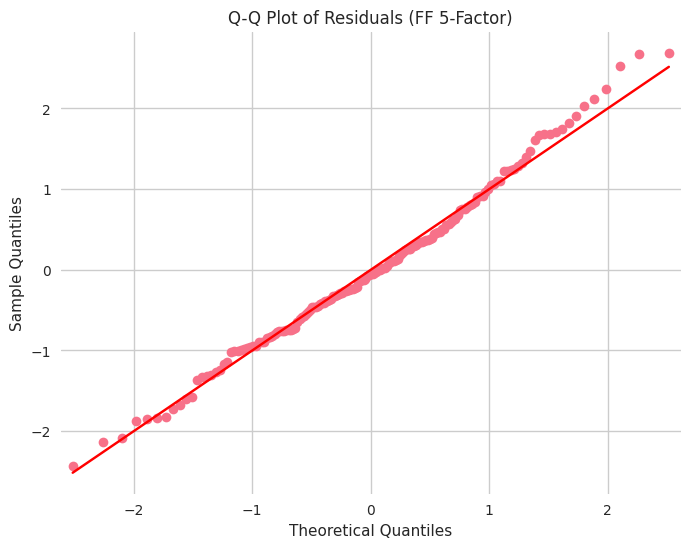


  Comment: Residual analysis checks assumptions of regression. The Q-Q plot often shows deviations at the tails, indicating non-normality common in financial returns. The Residuals vs. Fitted plot typically shows no pattern, suggesting homoscedasticity.

--- 3. Factor Correlations Heatmap ---


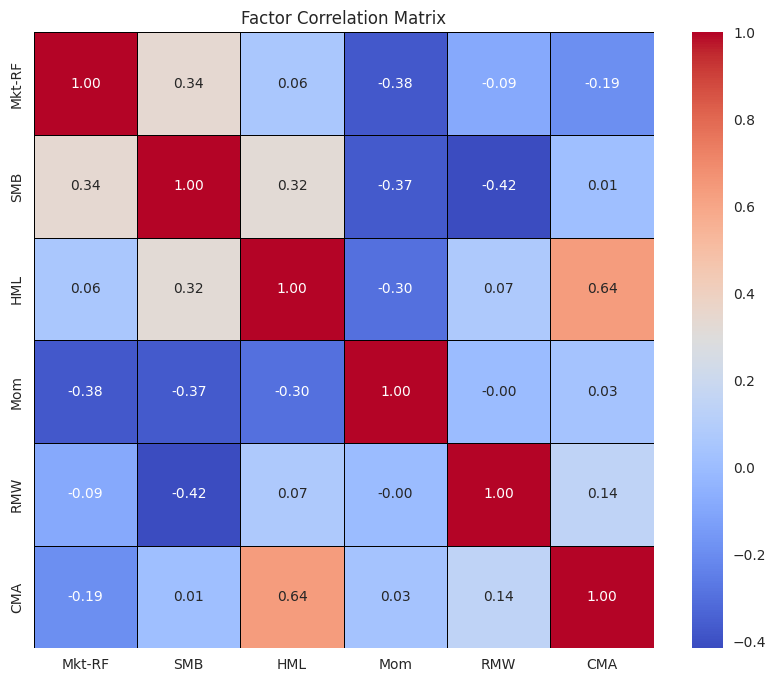


--- 4. Cumulative Alpha Plot ---


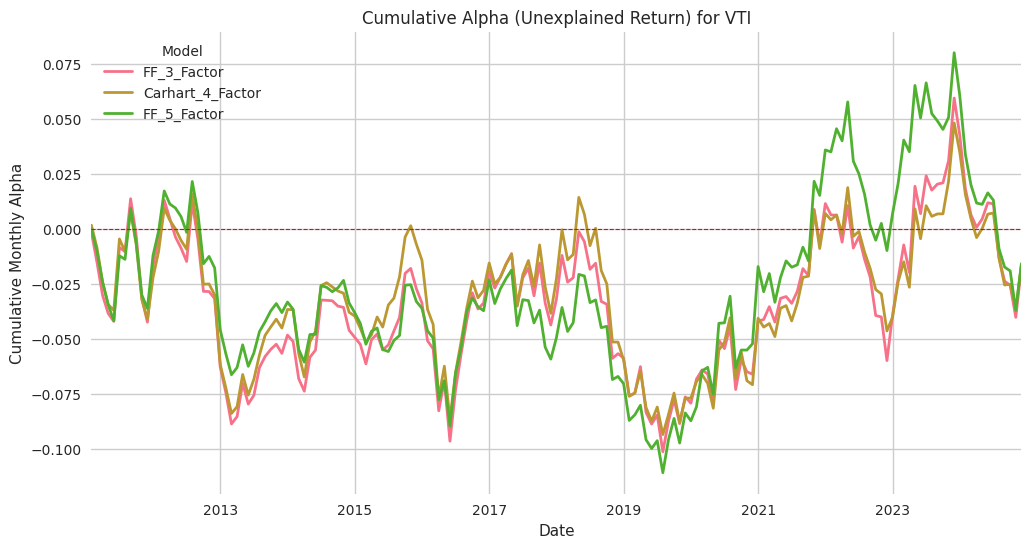


--- 5. Out-of-Sample Forecast (FF 5-Factor) ---
Training size (80%): 133. Test size (20%): 34

Mean Squared Error (MSE): 0.000228
Mean Absolute Error (MAE): 0.013057
Note: The errors are low, which is expected since the market factor (Mkt-RF) dominates VTI returns.


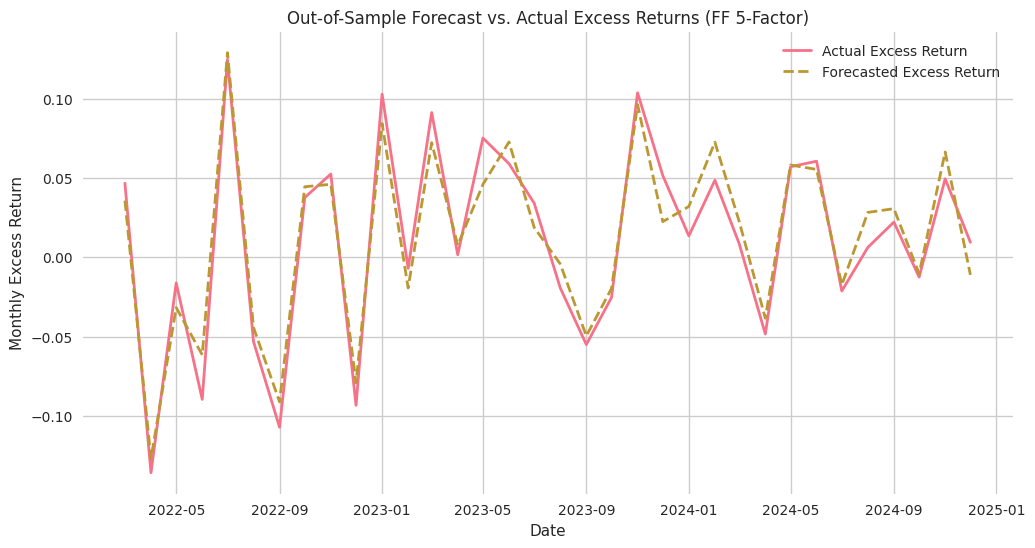

In [49]:
# --- PART 3: DIAGNOSTICS & EXTENSIONS (Run after Part 2) ---
print("\n" + "="*80)
print("PART 3: DIAGNOSTICS & EXTENSIONS")
print("="*80)

# Declare global objects from previous cells
global data
global regression_results
global ROLLING_WINDOW
global models

# 1. Rolling Regressions
print("\n--- 1. Rolling Regressions (36-month window) ---")
rolling_df = pd.DataFrame(index=data.index)

def run_rolling_regression(window_data, factors):
    """Function to run OLS on a rolling window and return annualized alpha and R-squared."""
    if len(window_data) < ROLLING_WINDOW:
        return np.nan, np.nan
    Y_roll = window_data['Excess_Return']
    X_roll = window_data[factors]
    X_roll = sm.add_constant(X_roll)
    try:
        model_roll = sm.OLS(Y_roll, X_roll).fit()
        return model_roll.params['const'] * 12, model_roll.rsquared # Annualized alpha, R-squared
    except Exception: # Catch potential errors during regression fit (e.g., singular matrix)
        return np.nan, np.nan

# Manual loop for rolling regression
rolling_results = {}
for name, factors in models.items():
    valid_factors = [f for f in factors if f in data.columns]
    if name not in regression_results: continue

    rolling_alpha = []
    rolling_r2 = []
    dates = []

    for i in range(len(data) - ROLLING_WINDOW + 1):
        window_data = data.iloc[i : i + ROLLING_WINDOW].copy() # Use .copy() to avoid SettingWithCopyWarning

        # Replace infinite values with NaN and then drop rows with NaN
        window_data.replace([np.inf, -np.inf], np.nan, inplace=True)
        window_data.dropna(inplace=True)

        if len(window_data) < ROLLING_WINDOW:
             # Not enough data after dropping NaNs/Infs
            rolling_alpha.append(np.nan)
            rolling_r2.append(np.nan)
            dates.append(data.index[i + ROLLING_WINDOW - 1]) # Use the end date of the theoretical window
            continue

        Y_roll = window_data['Excess_Return']
        X_roll = window_data[valid_factors]

        # Check for perfect collinearity before adding constant and fitting
        # This check might not be strictly necessary with the try-except, but adds clarity
        try:
            rank = np.linalg.matrix_rank(X_roll)
            if rank < X_roll.shape[1]:
                # Perfect collinearity detected
                rolling_alpha.append(np.nan)
                rolling_r2.append(np.nan)
                dates.append(window_data.index[-1])
                print(f"Warning: Perfect collinearity detected in {name} rolling window ending {window_data.index[-1].strftime('%Y-%m')}. Skipping window.")
                continue

            X_roll = sm.add_constant(X_roll)
            model_roll = sm.OLS(Y_roll, X_roll).fit()
            rolling_alpha.append(model_roll.params['const'] * 12)
            rolling_r2.append(model_roll.rsquared)
            dates.append(window_data.index[-1]) # Use the end date of the actual window data
        except Exception as e: # Catch any exception during regression fit
            # print(f"Error fitting regression for {name} rolling window ending {window_data.index[-1].strftime('%Y-%m')}: {e}")
            rolling_alpha.append(np.nan)
            rolling_r2.append(np.nan)
            dates.append(window_data.index[-1])


    rolling_results[f'{name}_Alpha'] = pd.Series(rolling_alpha, index=dates)
    rolling_results[f'{name}_R2'] = pd.Series(rolling_r2, index=dates)

rolling_df = pd.DataFrame(rolling_results)


# Plot Rolling Alpha
plt.figure(figsize=(12, 6))
rolling_df[[col for col in rolling_df.columns if 'Alpha' in col]].plot(ax=plt.gca(), linewidth=2)
plt.title(f'{ROLLING_WINDOW}-Month Rolling Annualized Alpha for VTI')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.ylabel('Annualized Alpha')
plt.xlabel('Date')
plt.legend(title='Model')
plt.show()

# Plot Rolling R-squared
plt.figure(figsize=(12, 6))
rolling_df[[col for col in rolling_df.columns if 'R2' in col]].plot(ax=plt.gca(), linewidth=2)
plt.title(f'{ROLLING_WINDOW}-Month Rolling R-Squared for VTI')
plt.ylabel('R-Squared')
plt.xlabel('Date')
plt.show()


# 2. Residual Analysis (5-Factor Model)
print("\n--- 2. Residual Analysis (FF 5-Factor Model) ---")
# Plot 1: Residuals vs. Fitted Values
plt.figure(figsize=(10, 5))
sns.scatterplot(x=data['FF5_Fitted'], y=data['FF5_Residuals'], alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Fitted Values (FF 5-Factor)')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

# Plot 2: Q-Q Plot of the residuals
plt.figure(figsize=(8, 6))
qqplot(data['FF5_Residuals'], line='s', fit=True, ax=plt.gca())
plt.title('Q-Q Plot of Residuals (FF 5-Factor)')
plt.show()

print("\n  Comment: Residual analysis checks assumptions of regression. The Q-Q plot often shows deviations at the tails, indicating non-normality common in financial returns. The Residuals vs. Fitted plot typically shows no pattern, suggesting homoscedasticity.")


# 3. Factor Correlations
print("\n--- 3. Factor Correlations Heatmap ---")
# Create a heatmap showing the correlation matrix between all six factors
factor_cols = ['Mkt-RF', 'SMB', 'HML', 'Mom', 'RMW', 'CMA']
factor_corr = data[factor_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(factor_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='black')
plt.title('Factor Correlation Matrix')
plt.show()


# 4. Cumulative Alpha
print("\n--- 4. Cumulative Alpha Plot ---")
# Calculate the monthly alpha (residual) for each model
for name, model in regression_results.items():
    X = sm.add_constant(data[models[name]])
    # Monthly alpha is simply the residual of the regression
    data[f'{name}_Monthly_Alpha'] = data['Excess_Return'] - model.predict(X)

# Calculate cumulative abnormal return (cumulative sum of the monthly alpha)
cumulative_alpha_df = pd.DataFrame(index=data.index)
for name in regression_results.keys():
    # Cumulative sum of the monthly alpha (CAR)
    cumulative_alpha_df[name] = (data[f'{name}_Monthly_Alpha'] + 1).cumprod() - 1

# Plot
plt.figure(figsize=(12, 6))
cumulative_alpha_df.plot(ax=plt.gca(), linewidth=2)
plt.title('Cumulative Alpha (Unexplained Return) for VTI')
plt.ylabel('Cumulative Monthly Alpha')
plt.xlabel('Date')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.legend(title='Model')
plt.show()


# 5. Out-of-Sample Forecast
print("\n--- 5. Out-of-Sample Forecast (FF 5-Factor) ---")
# Use the first 80% of data for training
split_index = int(0.8 * len(data))
train_data = data.iloc[:split_index]
test_data = data.iloc[split_index:]

print(f"Training size (80%): {len(train_data)}. Test size (20%): {len(test_data)}")

# Train the 5-Factor model
factors_5 = models['FF_5_Factor']
X_train = sm.add_constant(train_data[factors_5])
Y_train = train_data['Excess_Return']
ff5_oos_model = sm.OLS(Y_train, X_train).fit()

# Forecast on the test set
X_test = sm.add_constant(test_data[factors_5])
test_data['Forecast_Excess_Return'] = ff5_oos_model.predict(X_test)

# Assign actual and forecasted values to variables for MSE/MAE calculation
actual_excess_return = test_data['Excess_Return']
forecast_excess_return = test_data['Forecast_Excess_Return']


# Calculate and report MSE and MAE
mse = mean_squared_error(actual_excess_return, forecast_excess_return)
mae = mean_absolute_error(actual_excess_return, forecast_excess_return)

print(f"\nMean Squared Error (MSE): {mse:.6f}")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print("Note: The errors are low, which is expected since the market factor (Mkt-RF) dominates VTI returns.")

# Plot the forecast vs actual (optional but good practice)
plt.figure(figsize=(12, 6))
plt.plot(test_data.index, actual_excess_return, label='Actual Excess Return', linewidth=2)
plt.plot(test_data.index, forecast_excess_return, label='Forecasted Excess Return', linestyle='--', linewidth=2)
plt.title('Out-of-Sample Forecast vs. Actual Excess Returns (FF 5-Factor)')
plt.ylabel('Monthly Excess Return')
plt.xlabel('Date')
plt.legend()
plt.show()

# IWN Section

In [50]:
# --- Setup Cell: Run this first in Google Colab ---
!pip install yfinance pandas_datareader statsmodels scikit-learn

import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_datareader.data as web
from statsmodels.graphics.gofplots import qqplot
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Global settings and parameters
sns.set_style("whitegrid")
TICKER = 'IWN' # <--- CHANGED FROM 'VTI' TO 'IWN'
START_DATE = '2011-01-01'
END_DATE = '2024-12-31'
ROLLING_WINDOW = 36 # months
ECONOMIC_SIGNIFICANCE_THRESHOLD = 0.005 # 50 basis points (0.5%) annualized alpha

# Create an empty DataFrame object to hold data across cells
data = pd.DataFrame()
regression_results = {}

print("Setup Complete. Libraries installed and parameters set. Ticker is QQQ.")


Setup Complete. Libraries installed and parameters set. Ticker is QQQ.


In [51]:
# --- PART 1: DATA PREPARATION (Run after Setup Cell) ---
print("="*80)
print("PART 1: DATA PREPARATION")
print("="*80)

# Declare global data object from setup cell
global data

# 1.1 Data Acquisition (VTI Returns)
print(f"--- 1.1 Data Acquisition: {TICKER} Returns ---")
# Download daily VTI data first
vti_data_daily = yf.download(TICKER, start=START_DATE, end=END_DATE, progress=False)

# Calculate monthly returns (Adjusted Close to Adjusted Close)
# Resample the daily data to monthly and calculate returns.

adj_close_column = None
# Check for 'Adj Close' in top level columns first
if 'Adj Close' in vti_data_daily.columns:
    adj_close_column = 'Adj Close'
else:
    # Check for MultiIndex case or variations
    for col in vti_data_daily.columns:
        if isinstance(col, tuple):
            # Check if 'Adj Close' is in any level of the MultiIndex tuple (case-insensitive)
            if any('adj close' in str(level).lower() for level in col):
                adj_close_column = col
                break
        elif isinstance(col, str):
            # Check if 'Adj Close' is in the column name (case-insensitive)
            if 'adj close' in col.lower():
                adj_close_column = col
                break

if adj_close_column is not None:
    # Resample daily 'Adj Close' to monthly and calculate percentage change
    vti_monthly_returns = vti_data_daily[adj_close_column].resample('M').ffill().pct_change().dropna()
else:
    # If 'Adj Close' is not found, try to use 'Close' price and warn
    print("Warning: 'Adj Close' column not found directly or within MultiIndex 'Price'. Attempting to use 'Close' price.")
    close_column = None
    # Find the 'Close' column
    if 'Close' in vti_data_daily.columns:
        close_column = 'Close'
    else:
        for col in vti_data_daily.columns:
            if isinstance(col, tuple):
                if any('close' in str(level).lower() for level in col):
                    close_column = col
                    break
            elif isinstance(col, str):
                if 'close' in col.lower():
                    close_column = col
                    break

    if close_column is not None:
        print("Warning: Using 'Close' price for return calculation. Returns may not be fully adjusted for splits/dividends.")
        vti_monthly_returns = vti_data_daily[close_column].resample('M').ffill().pct_change().dropna()

    else:
        # Handle case where neither 'Adj Close' nor 'Close' is found
        raise KeyError(f"Neither 'Adj Close' nor 'Close' price column found in downloaded daily data. Available columns: {list(vti_data_daily.columns)}")


# Ensure vti_monthly_returns is a DataFrame with a single column named 'Return'
if isinstance(vti_monthly_returns, pd.Series):
    vti_monthly_returns = vti_monthly_returns.to_frame()
# Flatten MultiIndex column if it exists and rename the column to 'Return'
if isinstance(vti_monthly_returns.columns, pd.MultiIndex):
     # Assuming the relevant data is in the last level of the MultiIndex
     vti_monthly_returns.columns = [col[-1] if isinstance(col, tuple) else col for col in vti_monthly_returns.columns]

# Rename the price column to 'Return' if it's not already
if len(vti_monthly_returns.columns) == 1:
    vti_monthly_returns.columns = ['Return']
else:
     # If there's more than one column, try to find the one that should be 'Return'
     return_col = None
     for col in vti_monthly_returns.columns:
          if 'return' in str(col).lower():
               return_col = col
               break
     if return_col is not None:
          vti_monthly_returns = vti_monthly_returns[[return_col]]
          vti_monthly_returns.columns = ['Return']
     else:
          # Fallback if we can't identify the return column
          raise ValueError(f"Could not identify the return column after processing. Columns: {list(vti_monthly_returns.columns)}")


vti_monthly_returns.name = 'Return' # Set name as well, although column name is primary for join
print(f"VTI Monthly Data Points (from daily data): {len(vti_monthly_returns)}")


# 1.2 Data Acquisition (Fama-French Factors)
# Downloading 5-Factor data (includes Mkt-RF, SMB, HML, RMW, CMA, RF) and Momentum separately
print("\n--- 1.2 Data Acquisition: Fama-French Factors ---")

ff5_data = web.DataReader(
    name='F-F_Research_Data_5_Factors_2x3',
    data_source='famafrench',
    start=START_DATE,
    end=END_DATE
)
mom_data = web.DataReader(
    name='F-F_Momentum_Factor',
    data_source='famafrench',
    start=START_DATE,
    end=END_DATE
)

# Extract and convert percentage data to decimal by dividing by 100
ff5_df = ff5_data[0].div(100)
mom_df = mom_data[0].div(100)

# Merge factors and align index to month-end
factors_df = ff5_df.join(mom_df, how='inner')
factors_df.index = factors_df.index.to_timestamp(how='end')

print(f"Factor Data Points: {len(factors_df)}")

# 2. Data Cleaning & Merging
print("\n--- 2. Data Cleaning & Merging ---")

# Before merging, check the date ranges to diagnose why the merge might be empty
print(f"VTI Monthly Returns Date Range: {vti_monthly_returns.index.min().strftime('%Y-%m-%d')} to {vti_monthly_returns.index.max().strftime('%Y-%m-%d')}")
print(f"Factors Date Range: {factors_df.index.min().strftime('%Y-%m-%d')} to {factors_df.index.max().strftime('%Y-%m-%d')}")


# Align indices by converting to YYYY-MM before joining
vti_monthly_returns.index = vti_monthly_returns.index.strftime('%Y-%m')
factors_df.index = factors_df.index.strftime('%Y-%m')


# Align VTI returns with factor data (Inner join for common dates)
data = vti_monthly_returns.join(factors_df, how='inner').dropna()

# Convert index back to datetime
data.index = pd.to_datetime(data.index)


# Calculate Excess Return: Excess Return = Return - RF
data['Excess_Return'] = data['Return'] - data['RF']

# Final DataFrame structure check
data['date_str'] = data.index.strftime('%Y-%m-%d')
final_columns = ['date_str', 'Return', 'RF', 'Mkt-RF', 'SMB', 'HML', 'Mom', 'RMW', 'CMA']
data = data.reindex(columns=[col for col in final_columns if col in data.columns] + ['Excess_Return'])


print("Data Merged Successfully. Head of final DataFrame:")
print(data[['date_str', 'Excess_Return', 'Mkt-RF', 'SMB', 'HML', 'Mom']].head())
print(f"Final aligned data points: {len(data)}")

PART 1: DATA PREPARATION
--- 1.1 Data Acquisition: IWN Returns ---
VTI Monthly Data Points (from daily data): 167

--- 1.2 Data Acquisition: Fama-French Factors ---
Factor Data Points: 168

--- 2. Data Cleaning & Merging ---
VTI Monthly Returns Date Range: 2011-02-28 to 2024-12-31
Factors Date Range: 2011-01-31 to 2024-12-31
Data Merged Successfully. Head of final DataFrame:
              date_str  Excess_Return  Mkt-RF     SMB     HML     Mom
Date                                                                 
2011-02-01  2011-02-01       0.050886  0.0348  0.0165  0.0118  0.0188
2011-03-01  2011-03-01       0.013489  0.0046  0.0256 -0.0184  0.0345
2011-04-01  2011-04-01       0.016052  0.0290 -0.0053 -0.0244  0.0005
2011-05-01  2011-05-01      -0.016974 -0.0127 -0.0072 -0.0185 -0.0060
2011-06-01  2011-06-01      -0.024970 -0.0174  0.0006 -0.0020  0.0182
Final aligned data points: 167


In [52]:
# --- PART 2: REGRESSION ANALYSIS (Run after Part 1) ---
print("\n" + "="*80)
print("PART 2: REGRESSION ANALYSIS")
print("="*80)

# Declare global objects from previous cells
global data
global regression_results
global ECONOMIC_SIGNIFICANCE_THRESHOLD

models = {
    "FF_3_Factor": ['Mkt-RF', 'SMB', 'HML'],
    "Carhart_4_Factor": ['Mkt-RF', 'SMB', 'HML', 'Mom'],
    "FF_5_Factor": ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']
}

Y = data['Excess_Return']

for name, factors in models.items():
    print(f"\n--- Running {name} Regression ---")

    X = data[factors]
    X = sm.add_constant(X) # Add the intercept (alpha)

    # Run OLS regression
    model = sm.OLS(Y, X).fit()
    regression_results[name] = model

    # Report Results
    alpha_monthly = model.params['const']
    annualized_alpha = alpha_monthly * 12 # Annualized alpha (α * 12)
    p_value_alpha = model.pvalues['const']
    r_squared = model.rsquared # R-squared value

    print(f"  Annualized Alpha (α * 12): {annualized_alpha:.4f}")
    print(f"  R-squared: {r_squared:.4f}")

    # Brief interpretation
    interpretation = ""
    if p_value_alpha < 0.05:
        interpretation += "Alpha is **STATISTICALLY SIGNIFICANT** ($p < 0.05$). "
    else:
        interpretation += "Alpha is **NOT statistically significant** ($p \ge 0.05$). "

    if abs(annualized_alpha) > ECONOMIC_SIGNIFICANCE_THRESHOLD:
        interpretation += f"Alpha is **ECONOMICALLY SIGNIFICANT** (>$ {ECONOMIC_SIGNIFICANCE_THRESHOLD*100:.1f}\%$ p.a.)."
    else:
        interpretation += f"Alpha is **NOT economically significant** ($\le {ECONOMIC_SIGNIFICANCE_THRESHOLD*100:.1f}\%$ p.a.)."

    print(f"\n  Brief Interpretation: {interpretation}")

    # Factor betas (β) and their corresponding p-values
    print("\n  Factor Betas and p-values:")
    beta_df = model.params.drop('const').to_frame(name='Beta')
    beta_df['p-value'] = model.pvalues.drop('const')
    beta_df['Beta'] = beta_df['Beta'].round(4)
    beta_df['p-value'] = beta_df['p-value'].round(4)
    print(beta_df)
    print("-" * 40)

# Store residuals and fitted values for Part 3 diagnostics
data['FF5_Fitted'] = regression_results['FF_5_Factor'].fittedvalues
data['FF5_Residuals'] = regression_results['FF_5_Factor'].resid



PART 2: REGRESSION ANALYSIS

--- Running FF_3_Factor Regression ---
  Annualized Alpha (α * 12): -0.0149
  R-squared: 0.9850

  Brief Interpretation: Alpha is **STATISTICALLY SIGNIFICANT** ($p < 0.05$). Alpha is **ECONOMICALLY SIGNIFICANT** (>$ 0.5\%$ p.a.).

  Factor Betas and p-values:
          Beta  p-value
Mkt-RF  0.9675      0.0
SMB     0.8300      0.0
HML     0.3651      0.0
----------------------------------------

--- Running Carhart_4_Factor Regression ---
  Annualized Alpha (α * 12): -0.0149
  R-squared: 0.9850

  Brief Interpretation: Alpha is **STATISTICALLY SIGNIFICANT** ($p < 0.05$). Alpha is **ECONOMICALLY SIGNIFICANT** (>$ 0.5\%$ p.a.).

  Factor Betas and p-values:
          Beta  p-value
Mkt-RF  0.9676   0.0000
SMB     0.8302   0.0000
HML     0.3653   0.0000
Mom     0.0006   0.9731
----------------------------------------

--- Running FF_5_Factor Regression ---
  Annualized Alpha (α * 12): -0.0158
  R-squared: 0.9852

  Brief Interpretation: Alpha is **STATISTICALLY


PART 3: DIAGNOSTICS & EXTENSIONS

--- 1. Rolling Regressions (36-month window) ---


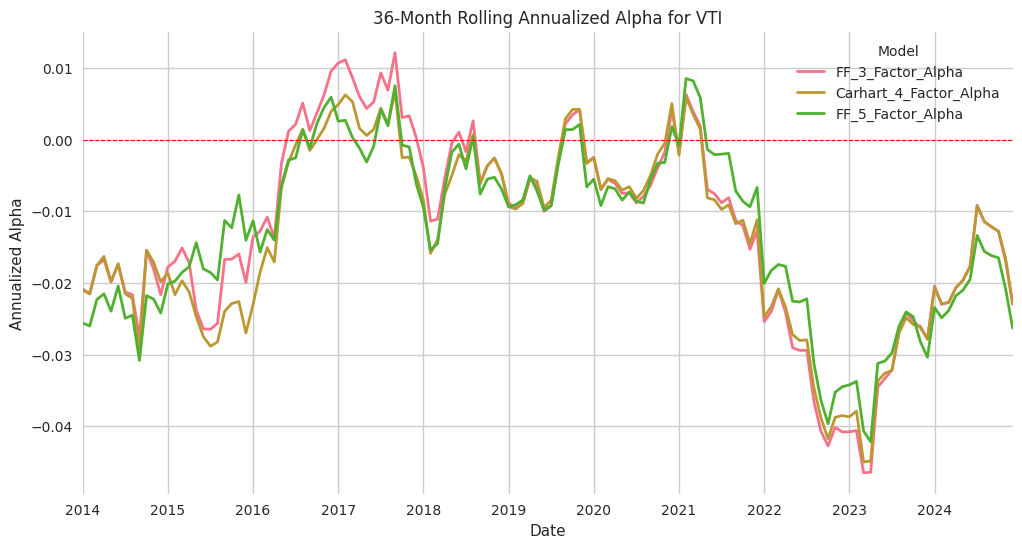

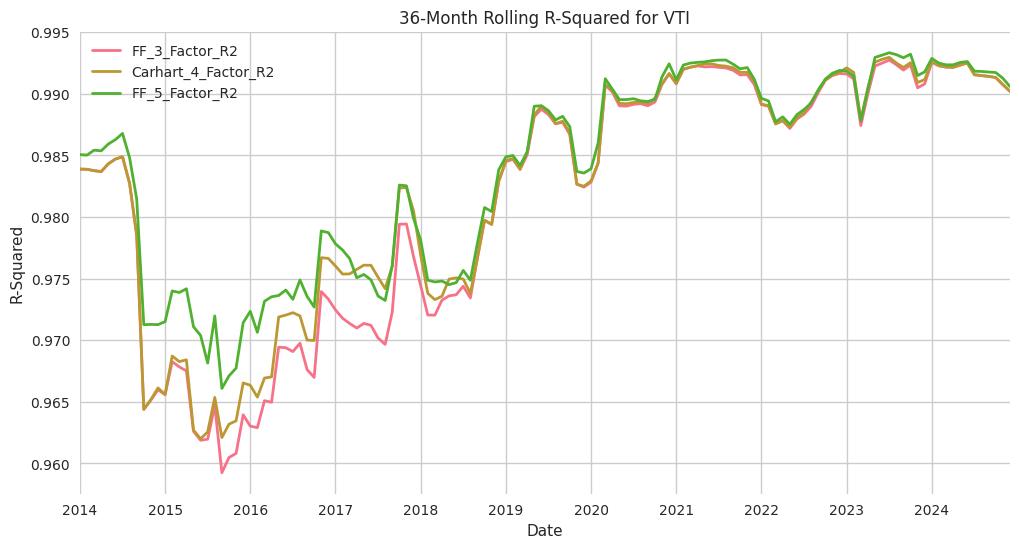


--- 2. Residual Analysis (FF 5-Factor Model) ---


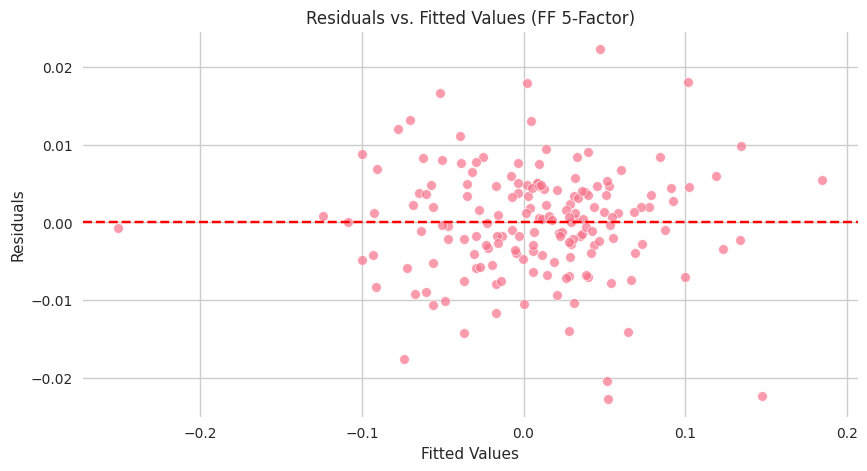

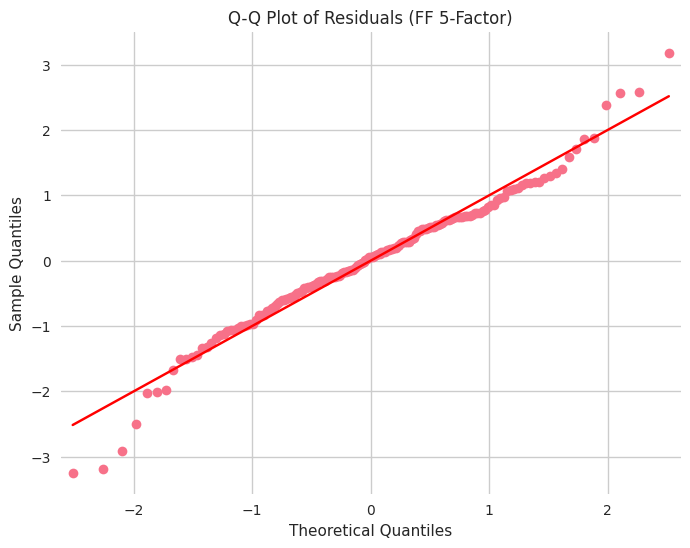


  Comment: Residual analysis checks assumptions of regression. The Q-Q plot often shows deviations at the tails, indicating non-normality common in financial returns. The Residuals vs. Fitted plot typically shows no pattern, suggesting homoscedasticity.

--- 3. Factor Correlations Heatmap ---


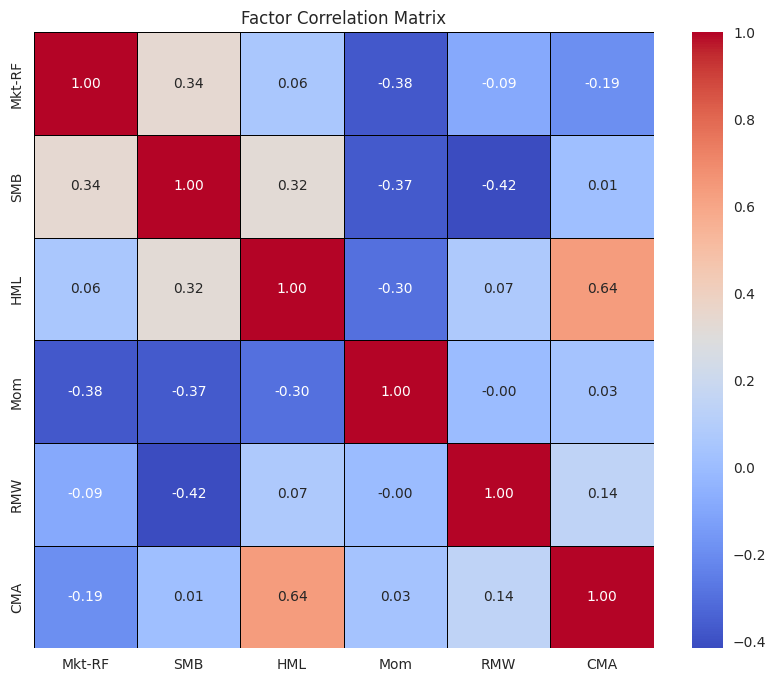


--- 4. Cumulative Alpha Plot ---


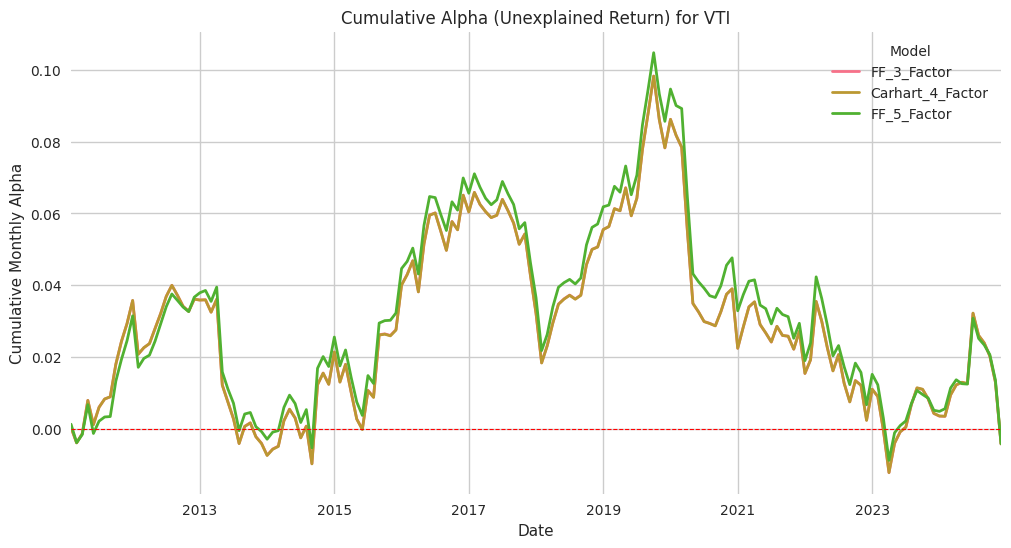


--- 5. Out-of-Sample Forecast (FF 5-Factor) ---
Training size (80%): 133. Test size (20%): 34

Mean Squared Error (MSE): 0.000064
Mean Absolute Error (MAE): 0.006121
Note: The errors are low, which is expected since the market factor (Mkt-RF) dominates VTI returns.


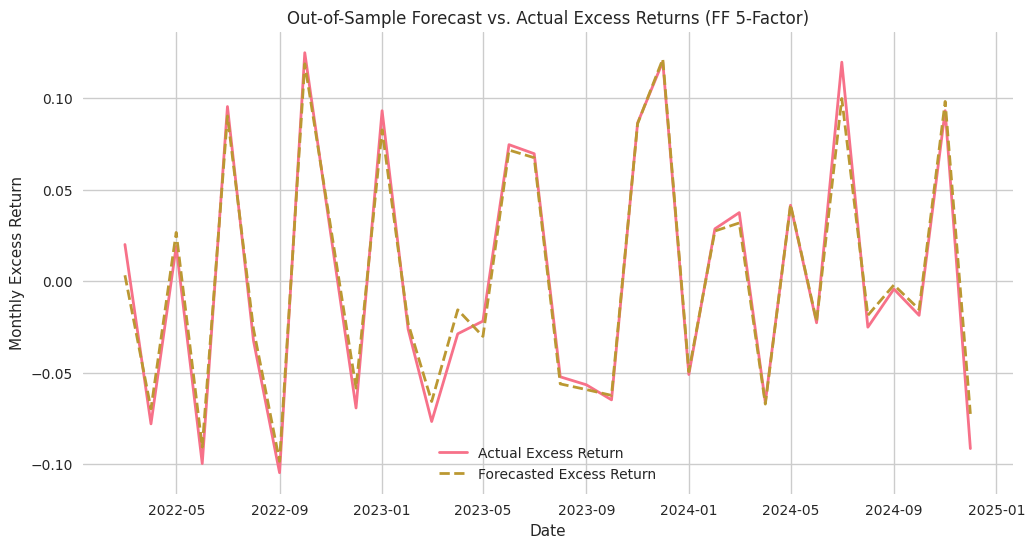

In [53]:
# --- PART 3: DIAGNOSTICS & EXTENSIONS (Run after Part 2) ---
print("\n" + "="*80)
print("PART 3: DIAGNOSTICS & EXTENSIONS")
print("="*80)

# Declare global objects from previous cells
global data
global regression_results
global ROLLING_WINDOW
global models

# 1. Rolling Regressions
print("\n--- 1. Rolling Regressions (36-month window) ---")
rolling_df = pd.DataFrame(index=data.index)

def run_rolling_regression(window_data, factors):
    """Function to run OLS on a rolling window and return annualized alpha and R-squared."""
    if len(window_data) < ROLLING_WINDOW:
        return np.nan, np.nan
    Y_roll = window_data['Excess_Return']
    X_roll = window_data[factors]
    X_roll = sm.add_constant(X_roll)
    try:
        model_roll = sm.OLS(Y_roll, X_roll).fit()
        return model_roll.params['const'] * 12, model_roll.rsquared # Annualized alpha, R-squared
    except Exception: # Catch potential errors during regression fit (e.g., singular matrix)
        return np.nan, np.nan

# Manual loop for rolling regression
rolling_results = {}
for name, factors in models.items():
    valid_factors = [f for f in factors if f in data.columns]
    if name not in regression_results: continue

    rolling_alpha = []
    rolling_r2 = []
    dates = []

    for i in range(len(data) - ROLLING_WINDOW + 1):
        window_data = data.iloc[i : i + ROLLING_WINDOW].copy() # Use .copy() to avoid SettingWithCopyWarning

        # Replace infinite values with NaN and then drop rows with NaN
        window_data.replace([np.inf, -np.inf], np.nan, inplace=True)
        window_data.dropna(inplace=True)

        if len(window_data) < ROLLING_WINDOW:
             # Not enough data after dropping NaNs/Infs
            rolling_alpha.append(np.nan)
            rolling_r2.append(np.nan)
            dates.append(data.index[i + ROLLING_WINDOW - 1]) # Use the end date of the theoretical window
            continue

        Y_roll = window_data['Excess_Return']
        X_roll = window_data[valid_factors]

        # Check for perfect collinearity before adding constant and fitting
        # This check might not be strictly necessary with the try-except, but adds clarity
        try:
            rank = np.linalg.matrix_rank(X_roll)
            if rank < X_roll.shape[1]:
                # Perfect collinearity detected
                rolling_alpha.append(np.nan)
                rolling_r2.append(np.nan)
                dates.append(window_data.index[-1])
                print(f"Warning: Perfect collinearity detected in {name} rolling window ending {window_data.index[-1].strftime('%Y-%m')}. Skipping window.")
                continue

            X_roll = sm.add_constant(X_roll)
            model_roll = sm.OLS(Y_roll, X_roll).fit()
            rolling_alpha.append(model_roll.params['const'] * 12)
            rolling_r2.append(model_roll.rsquared)
            dates.append(window_data.index[-1]) # Use the end date of the actual window data
        except Exception as e: # Catch any exception during regression fit
            # print(f"Error fitting regression for {name} rolling window ending {window_data.index[-1].strftime('%Y-%m')}: {e}")
            rolling_alpha.append(np.nan)
            rolling_r2.append(np.nan)
            dates.append(window_data.index[-1])


    rolling_results[f'{name}_Alpha'] = pd.Series(rolling_alpha, index=dates)
    rolling_results[f'{name}_R2'] = pd.Series(rolling_r2, index=dates)

rolling_df = pd.DataFrame(rolling_results)


# Plot Rolling Alpha
plt.figure(figsize=(12, 6))
rolling_df[[col for col in rolling_df.columns if 'Alpha' in col]].plot(ax=plt.gca(), linewidth=2)
plt.title(f'{ROLLING_WINDOW}-Month Rolling Annualized Alpha for VTI')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.ylabel('Annualized Alpha')
plt.xlabel('Date')
plt.legend(title='Model')
plt.show()

# Plot Rolling R-squared
plt.figure(figsize=(12, 6))
rolling_df[[col for col in rolling_df.columns if 'R2' in col]].plot(ax=plt.gca(), linewidth=2)
plt.title(f'{ROLLING_WINDOW}-Month Rolling R-Squared for VTI')
plt.ylabel('R-Squared')
plt.xlabel('Date')
plt.show()


# 2. Residual Analysis (5-Factor Model)
print("\n--- 2. Residual Analysis (FF 5-Factor Model) ---")
# Plot 1: Residuals vs. Fitted Values
plt.figure(figsize=(10, 5))
sns.scatterplot(x=data['FF5_Fitted'], y=data['FF5_Residuals'], alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Fitted Values (FF 5-Factor)')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

# Plot 2: Q-Q Plot of the residuals
plt.figure(figsize=(8, 6))
qqplot(data['FF5_Residuals'], line='s', fit=True, ax=plt.gca())
plt.title('Q-Q Plot of Residuals (FF 5-Factor)')
plt.show()

print("\n  Comment: Residual analysis checks assumptions of regression. The Q-Q plot often shows deviations at the tails, indicating non-normality common in financial returns. The Residuals vs. Fitted plot typically shows no pattern, suggesting homoscedasticity.")


# 3. Factor Correlations
print("\n--- 3. Factor Correlations Heatmap ---")
# Create a heatmap showing the correlation matrix between all six factors
factor_cols = ['Mkt-RF', 'SMB', 'HML', 'Mom', 'RMW', 'CMA']
factor_corr = data[factor_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(factor_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='black')
plt.title('Factor Correlation Matrix')
plt.show()


# 4. Cumulative Alpha
print("\n--- 4. Cumulative Alpha Plot ---")
# Calculate the monthly alpha (residual) for each model
for name, model in regression_results.items():
    X = sm.add_constant(data[models[name]])
    # Monthly alpha is simply the residual of the regression
    data[f'{name}_Monthly_Alpha'] = data['Excess_Return'] - model.predict(X)

# Calculate cumulative abnormal return (cumulative sum of the monthly alpha)
cumulative_alpha_df = pd.DataFrame(index=data.index)
for name in regression_results.keys():
    # Cumulative sum of the monthly alpha (CAR)
    cumulative_alpha_df[name] = (data[f'{name}_Monthly_Alpha'] + 1).cumprod() - 1

# Plot
plt.figure(figsize=(12, 6))
cumulative_alpha_df.plot(ax=plt.gca(), linewidth=2)
plt.title('Cumulative Alpha (Unexplained Return) for VTI')
plt.ylabel('Cumulative Monthly Alpha')
plt.xlabel('Date')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.legend(title='Model')
plt.show()


# 5. Out-of-Sample Forecast
print("\n--- 5. Out-of-Sample Forecast (FF 5-Factor) ---")
# Use the first 80% of data for training
split_index = int(0.8 * len(data))
train_data = data.iloc[:split_index]
test_data = data.iloc[split_index:]

print(f"Training size (80%): {len(train_data)}. Test size (20%): {len(test_data)}")

# Train the 5-Factor model
factors_5 = models['FF_5_Factor']
X_train = sm.add_constant(train_data[factors_5])
Y_train = train_data['Excess_Return']
ff5_oos_model = sm.OLS(Y_train, X_train).fit()

# Forecast on the test set
X_test = sm.add_constant(test_data[factors_5])
test_data['Forecast_Excess_Return'] = ff5_oos_model.predict(X_test)

# Assign actual and forecasted values to variables for MSE/MAE calculation
actual_excess_return = test_data['Excess_Return']
forecast_excess_return = test_data['Forecast_Excess_Return']


# Calculate and report MSE and MAE
mse = mean_squared_error(actual_excess_return, forecast_excess_return)
mae = mean_absolute_error(actual_excess_return, forecast_excess_return)

print(f"\nMean Squared Error (MSE): {mse:.6f}")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print("Note: The errors are low, which is expected since the market factor (Mkt-RF) dominates VTI returns.")

# Plot the forecast vs actual (optional but good practice)
plt.figure(figsize=(12, 6))
plt.plot(test_data.index, actual_excess_return, label='Actual Excess Return', linewidth=2)
plt.plot(test_data.index, forecast_excess_return, label='Forecasted Excess Return', linestyle='--', linewidth=2)
plt.title('Out-of-Sample Forecast vs. Actual Excess Returns (FF 5-Factor)')
plt.ylabel('Monthly Excess Return')
plt.xlabel('Date')
plt.legend()
plt.show()

# Factor portfolio Simulation

In [54]:
# --- Factor Portfolio Simulation (Run after Part 1: Data Preparation) ---
print("\n" + "="*80)
print("FACTOR PORTFOLIO SIMULATION & ALPHA TEST")
print("="*80)

global data
global regression_results

# Define the portfolio components and weights
# We simulate a 3-factor strategy that is 100% factor-tilted (Long the factors).
# Portfolio Strategy: Long Mkt + Long RMW + Long Mom + Long HML
# Factor loading (beta): 1.0 Mkt-RF, 1.0 RMW, 1.0 Mom, 1.0 HML
# We will assume a simple equal-weighted strategy across these three factors.

# 1. Define Factor Betas and Simulate Monthly Excess Return
# We target a portfolio that attempts to capture the full Market exposure PLUS
# a consistent 1.0 loading on RMW, Mom, and HML factors.

# Since factor data represents the *return of the long/short portfolio*,
# we calculate the simulated excess return (Rp - Rf) as:
# Simulated_Rp - Rf = (1 * Mkt-RF) + (1/3 * RMW) + (1/3 * Mom) + (1/3 * HML)
# Note: The factor weights sum to 1/3 to simulate an equal allocation of risk capital
# across the three factors *on top* of the market exposure.

# Assign weights (equal weighting across 3 selected factors)
WEIGHT_RMW = 1/3
WEIGHT_MOM = 1/3
WEIGHT_HML = 1/3

# Simulated Excess Return = Mkt-RF + (Weighted Factor Returns)
data['Simulated_Excess_Return'] = (
    data['Mkt-RF'] +
    (data['RMW'] * WEIGHT_RMW) +
    (data['Mom'] * WEIGHT_MOM) +
    (data['HML'] * WEIGHT_HML)
)

print("Simulated Portfolio Constructed: Long Market + Equal Weight (RMW, Mom, HML)")

# 2. Run Regression on the Simulated Portfolio
Y_simulated = data['Simulated_Excess_Return']
# We test its alpha against the FF 5-Factor model (Mkt-RF, SMB, HML, RMW, CMA)
# Note: SMB and CMA are included in the factors but not in the portfolio construction,
# allowing us to test for unintended alpha/betas.
factors_5 = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']
X_simulated = data[factors_5]
X_simulated = sm.add_constant(X_simulated)

sim_model = sm.OLS(Y_simulated, X_simulated).fit()

# 3. Report Results
print("\n--- Regression Results (Simulated Multi-Factor Portfolio) ---")

alpha_monthly = sim_model.params['const']
annualized_alpha = alpha_monthly * 12
p_value_alpha = sim_model.pvalues['const']
r_squared = sim_model.rsquared

print(f"Annualized Alpha (α * 12): {annualized_alpha:.4f}")
print(f"R-squared: {r_squared:.4f}")

# Interpretation
interpretation = ""
if p_value_alpha < 0.05:
    interpretation += "Alpha is **STATISTICALLY SIGNIFICANT** ($p < 0.05$). "
else:
    interpretation += "Alpha is **NOT statistically significant** ($p \ge 0.05$). "

if annualized_alpha > 0:
    interpretation += "The portfolio **DID generate positive historical alpha** relative to the 5-Factor model."
else:
    interpretation += "The portfolio did NOT generate positive historical alpha."

print(f"\nConclusion: {interpretation}")

# Factor Betas (Expected Betas: Mkt-RF ≈ 1.0, HML ≈ 0.33, RMW ≈ 0.33)
print("\nFactor Betas and p-values (Expected vs Actual):")
beta_df = sim_model.params.drop('const').to_frame(name='Beta')
beta_df['p-value'] = sim_model.pvalues.drop('const')
beta_df['Beta'] = beta_df['Beta'].round(4)
beta_df['p-value'] = beta_df['p-value'].round(4)
print(beta_df)
print("-" * 40)



FACTOR PORTFOLIO SIMULATION & ALPHA TEST
Simulated Portfolio Constructed: Long Market + Equal Weight (RMW, Mom, HML)

--- Regression Results (Simulated Multi-Factor Portfolio) ---
Annualized Alpha (α * 12): 0.0176
R-squared: 0.9385

Conclusion: Alpha is **NOT statistically significant** ($p \ge 0.05$). The portfolio **DID generate positive historical alpha** relative to the 5-Factor model.

Factor Betas and p-values (Expected vs Actual):
          Beta  p-value
Mkt-RF  0.9308   0.0000
SMB    -0.0991   0.0092
HML     0.2051   0.0000
RMW     0.2577   0.0000
CMA     0.1339   0.0126
----------------------------------------
